In [1]:
import numpy as np
import matplotlib

import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist
import mdtraj as md
from sklearn.decomposition import PCA
from IPython.display import display
import ipywidgets as widgets
from deeptime.decomposition import TICA
from sklearn.cluster import KMeans
from deeptime.markov.msm import MaximumLikelihoodMSM

In [3]:
# Load and slice Cα atoms
traj_paths = [
    ('XX.dcd', 'XX.prmtop')
    # Add more as needed
]


ca_trajs = []
for traj_file, top_file in traj_paths:
    traj = md.load(traj_file, top=top_file)
    ca_idx = traj.topology.select('name CA')
    ca_traj = traj.atom_slice(ca_idx)
    ca_traj.superpose(ca_traj[0])  # Align each to first frame
    ca_trajs.append(ca_traj)


In [4]:
ca_trajs

[<mdtraj.Trajectory with 7959 frames, 790 atoms, 395 residues, and unitcells at 0x7fd6f847b1f0>]

In [5]:

holo_topology_path = 'comp_solv.prmtop'
holo_trajectory_paths = [
    'md_1000.nc'
]

cutoff = 0.5  # in nanometers (1 nm = 10 Å)

traj = md.load(holo_trajectory_paths, top=holo_topology_path)
traj_holo = traj

#  Identify protein atoms near ligand 
ligand_atoms = traj.topology.select('resname d7')
protein_atoms = traj.topology.select('protein')

# Compute neighbors: atoms within cutoff nm of ligand atoms in frame 0
neighbors = md.compute_neighbors(
    traj[0], cutoff, query_indices=ligand_atoms, haystack_indices=protein_atoms
)[0]

#Extract unique residues
binding_pocket_resids = sorted(set(traj.topology.atom(i).residue.resSeq for i in neighbors))
binding_pocket_resnames = [
    f"{traj.topology.atom(i).residue.name}{traj.topology.atom(i).residue.resSeq}"
    for i in neighbors
]
binding_pocket_resnames = sorted(set(binding_pocket_resnames))

#print("Ligand atom indices:", ligand_atoms)

#  Print nicely
print("Binding site residue IDs:",",".join(map(str, binding_pocket_resids)))
print("Binding site residue IDs1:"," ".join(map(str, binding_pocket_resids)))
print("Binding site residues:"," ".join(binding_pocket_resnames))


Binding site residue IDs: 237,238,239,240,241,242,243,244,245,256,257,258,262,263,264,345,346,347,348,370,371,372,373,374
Binding site residue IDs1: 237 238 239 240 241 242 243 244 245 256 257 258 262 263 264 345 346 347 348 370 371 372 373 374
Binding site residues: ALA372 ARG237 ASN239 ASN345 ASP348 GLN258 GLY241 GLY262 HIS374 ILE370 LEU245 LYS242 LYS346 MET373 PRO238 SER243 SER371 THR244 THR264 VAL240 VAL256 VAL257 VAL263 VAL347


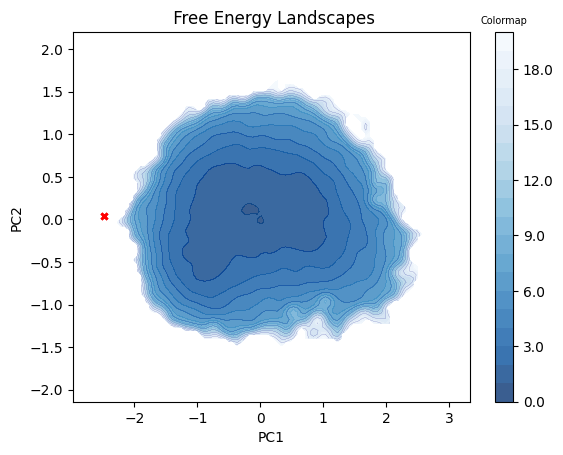

In [9]:
from scipy.ndimage import gaussian_filter


def compute_fel(proj, nbins=100, kT=2.479, sigma=2):
    x = proj[:, 0]
    y = proj[:, 1]

    H, xedges, yedges = np.histogram2d(x, y, bins=nbins, density=True)
    H[H <= 1e-10] = 1e-10
    F = -kT * np.log(H)
    F -= np.min(F)
    F = gaussian_filter(F, sigma=sigma)
    F = np.ma.masked_where(F > 20, F)

    X, Y = 0.5 * (xedges[:-1] + xedges[1:]), 0.5 * (yedges[:-1] + yedges[1:])
    X, Y = np.meshgrid(X, Y)

    return X, Y, F

X_PCA_1, Y_PCA_1, F_PCA_1 = compute_fel(X_pca_proj, sigma=1.5)

cf = plt.contourf(X_PCA_1, Y_PCA_1, F_PCA_1.T, levels=20, cmap='Blues_r', alpha=0.8)
c = plt.contour(X_PCA_1, Y_PCA_1, F_PCA_1.T, levels=10, colors='navy', linewidths=0.1)

#plt.legend(cf1, fontsize=8, colors='black')

cbar1 = plt.colorbar(cf, format='%.1f')
cbar1.ax.set_title('Colormap', fontsize=7)


############################
#put red cross
# Starting structure (first frame)
x0, y0 = X_pca_proj[0, 0], X_pca_proj[0, 1]

# Plot red cross
plt.plot(x0, y0, marker='x', color='red',
         markersize=4, markeredgewidth=2,
         label='Start')
plt.scatter(x0, y0, s=20, marker='x', c='red', linewidths=2)
#plt.legend(loc='upper right', fontsize=8, frameon=True)

############################

# Labels and layout
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title(' Free Energy Landscapes')
#plt.tight_layout()
plt.savefig('pca_fel.png', dpi=600)
plt.show()

In [11]:
#%%script false --no-raise-error
##Code to save structures from the minima..The centroid pdbs as 
matplotlib.use('Qt5Agg')

# Enable interactive plotting
%matplotlib qt

# Ensure these are already defined:
# X_PCA_1, Y_PCA_1, F_PCA_1 (FES grid)
# X_pca_proj (PCA coordinates of all frames)
# ca_trajs (list of Cα-only MDTraj objects)
# wt_cumsum (cumulative frame index lookup)


wt_lengths = [traj.n_frames for traj in ca_trajs]
wt_cumsum = np.cumsum([0] + wt_lengths)

def find_source_frame(global_idx):
    for i in range(len(wt_cumsum) - 1):
        if wt_cumsum[i] <= global_idx < wt_cumsum[i+1]:
            return i, global_idx - wt_cumsum[i]
    return None, None

fig, ax = plt.subplots(figsize=(8, 6))
cf = ax.contourf(X_PCA_1, Y_PCA_1, F_PCA_1.T, levels=40, cmap='Blues_r', alpha=0.8)
c = plt.contour(X_PCA_1, Y_PCA_1, F_PCA_1.T, levels=10, colors='navy', linewidths=0.5)
plt.colorbar(cf, label='Free Energy (kT)')
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Click on PCA FES to extract centroid structure")

click_counter = 0
k_nearest = 500

# Helper: Locate the original trajectory/frame
def find_source_frame(global_idx):
    for i in range(len(wt_cumsum) - 1):
        if wt_cumsum[i] <= global_idx < wt_cumsum[i + 1]:
            return i, global_idx - wt_cumsum[i]
    return None, None

# On-click handler
proj_data = X_pca_proj  # change here
click_counter = 0


def onclick(event):
    global click_counter
    x_click, y_click = event.xdata, event.ydata
    if x_click is None or y_click is None:
        return

    distances = cdist(proj_data, [[x_click, y_click]])
    nearest_idxs = np.argsort(distances[:, 0])[:k_nearest]
    print(f" Found {k_nearest} nearest frames..Wait for me to save the dcd....")
    
    point_size = max(20, len(nearest_idxs) * 2)
    print(f"\n Clicked at: PC1={x_click:.3f}, PC2={y_click:.3f}")
    ax.scatter([x_click], [y_click], s=point_size, c='red', edgecolor='black', alpha=0.5)
    fig.canvas.draw()

    aligned_xyz = []
    ref_frame = None

    for idx in nearest_idxs:
        traj_idx, frame_idx = find_source_frame(idx)
        if traj_idx is None:
            print("Invalid frame index.")
            continue
        
        try:
            frame = traj[frame_idx]
            if ref_frame is None:
                ref_frame = frame
            frame.superpose(ref_frame)
            aligned_xyz.append(frame.xyz[0])
        except Exception as e:
            print(f" Skipping frame due to error: {e}")
            continue

    if not aligned_xyz or ref_frame is None:
        print("No valid frames found")
        return

    try:
        centroid_traj = md.Trajectory(aligned_xyz, ref_frame.topology)
        output_name = f"pca_minima{click_counter + 1}.dcd" # change here
        centroid_traj.save(output_name)
        print(f" Saved structures to: {output_name}")
        click_counter += 1
    except Exception as e:
        print(f" Error computing or saving structures: {e}")

# -----------------------------------------
#  Connect the click handler
# -----------------------------------------
fig.canvas.mpl_connect('button_press_event', onclick)
plt.tight_layout()
plt.show()

 Found 500 nearest frames..Wait for me to save the dcd....

 Clicked at: PC1=-0.178, PC2=0.120
 Saved structures to: pca_minima1.dcd
